In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/online_retail.csv",
    encoding="latin1"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [6]:
df=df.dropna(subset=['CustomerID'])

In [7]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
monthly_revenue = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum().reset_index()
monthly_revenue["InvoiceDate"] = monthly_revenue["InvoiceDate"].dt.to_timestamp()

<Axes: title={'center': 'Monthly Revenue'}, xlabel='InvoiceDate'>

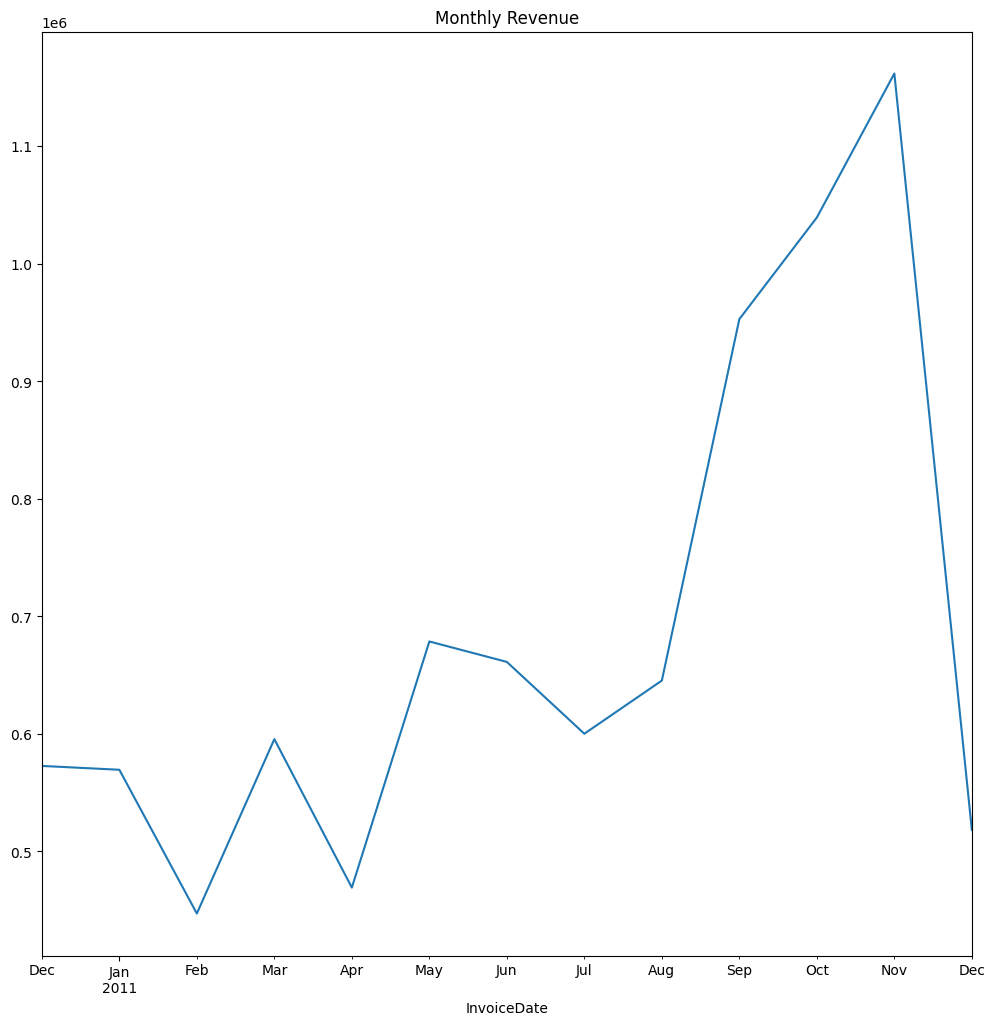

In [10]:
monthly_revenue =(df.set_index("InvoiceDate").resample("ME")["Revenue"].sum())
monthly_revenue.plot(figsize=(12, 12), title="Monthly Revenue")

In [11]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [12]:
monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,InvoiceDate,Revenue
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361
5,2011-05,678594.560
6,2011-06,661213.690
7,2011-07,600091.011
8,2011-08,645343.900
9,2011-09,952838.382


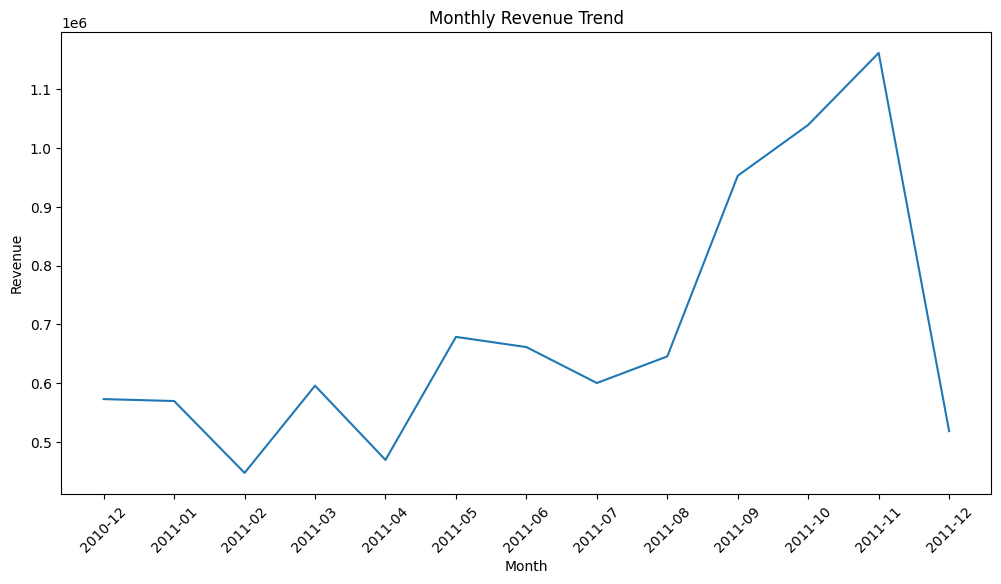

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["InvoiceDate"].astype(str),
    monthly_revenue["Revenue"]
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

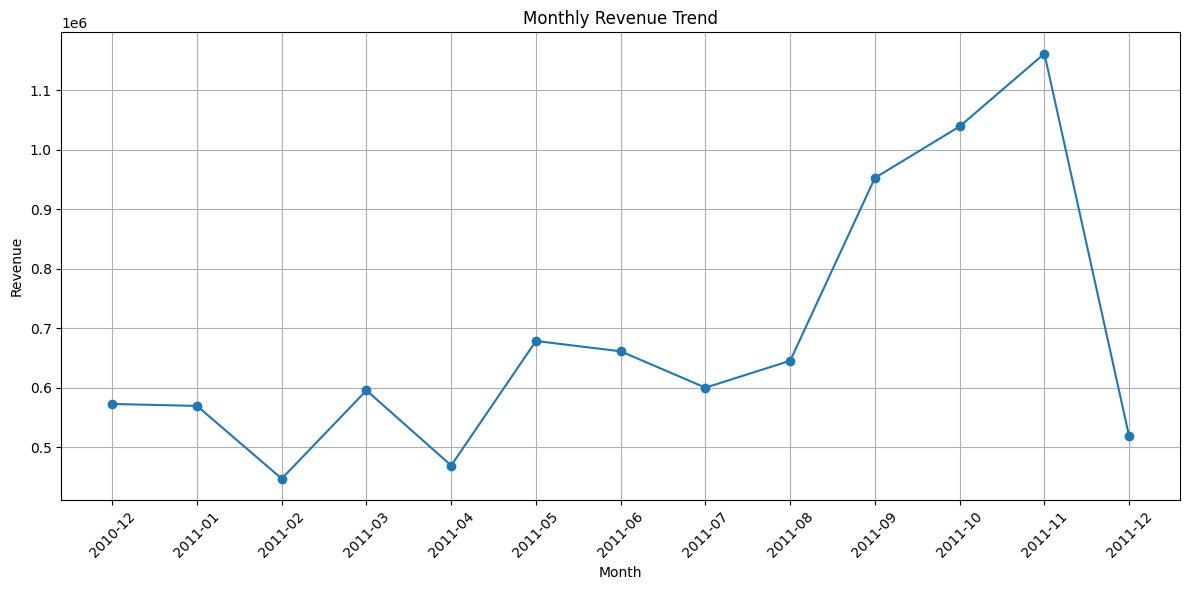

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["InvoiceDate"].astype(str),
    monthly_revenue["Revenue"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

In [15]:
value_counts = df["Country"].value_counts()
print(value_counts)

Country
United Kingdom          354345
Germany                   9042
France                    8342
EIRE                      7238
Spain                     2485
Netherlands               2363
Belgium                   2031
Switzerland               1842
Portugal                  1462
Australia                 1185
Norway                    1072
Italy                      758
Channel Islands            748
Finland                    685
Cyprus                     614
Sweden                     451
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     248
Unspecified                244
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         58
Lebanon                     45


In [16]:
value_counts = df["Revenue"].value_counts()
print(value_counts)

Revenue
15.00        20082
17.70         9174
16.50         8490
10.20         8028
19.80         7625
             ...  
168469.60        1
533.40           1
25.08            1
469.44           1
66.36            1
Name: count, Length: 2940, dtype: int64


In [17]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

In [18]:
top_customers = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [19]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

In [20]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [21]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [22]:
df[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [23]:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

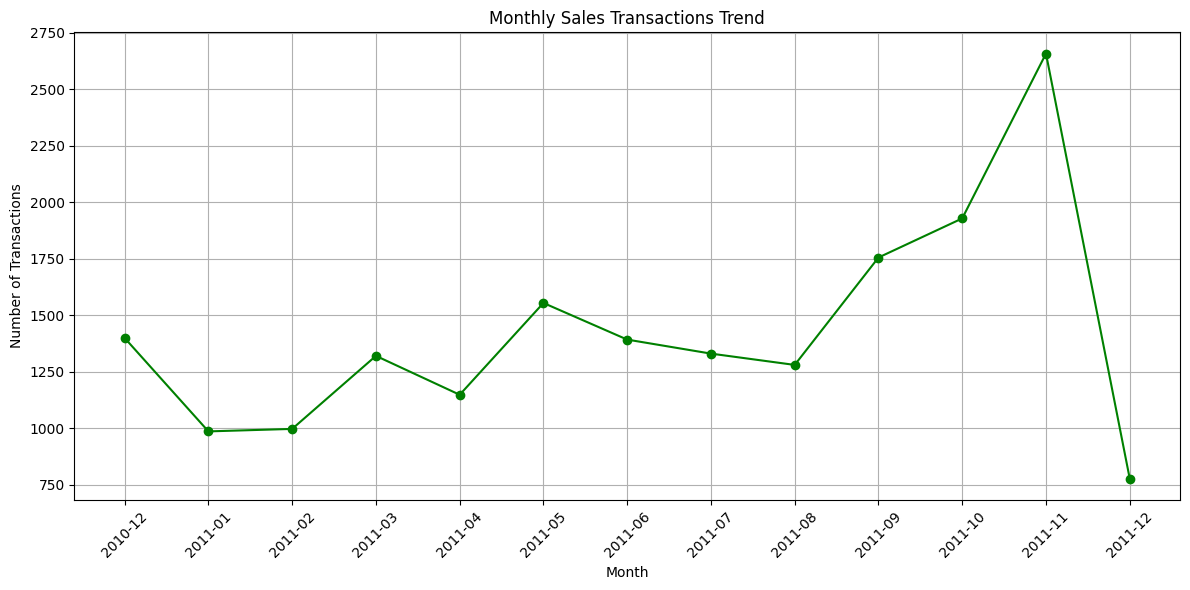

In [24]:
# Monthly Sales Count / Transactions Chart
plt.figure(figsize=(12,6))

monthly_revenue["TransactionCount"] = df.groupby("Month")["InvoiceNo"].nunique().values

plt.plot(
    monthly_revenue["Month"].astype(str),
    monthly_revenue["TransactionCount"],  # işlem sayısı
    marker="o",
    color='green'
)

plt.xticks(rotation=45)
plt.title("Monthly Sales Transactions Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.tight_layout()
plt.show()